<a href="https://colab.research.google.com/github/krushna1133/NNDL-Practical/blob/main/NNDL_Practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

model = models.Sequential([
   layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(64, (3, 3), activation='relu'),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(64, (3, 3), activation='relu'),
   layers.Flatten(),
   layers.Dense(64, activation='relu'),
   layers.Dense(10)
])

model.compile(optimizer='adam',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
             metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                   validation_data=(test_images, test_labels))



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.8173 - loss: 0.5030 - val_accuracy: 0.8658 - val_loss: 0.3695
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8819 - loss: 0.3202 - val_accuracy: 0.8759 - val_loss: 0.3261
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.8989 - loss: 0.2748 - val_accuracy: 0.8936 - val_loss: 0.2872
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9100 - loss: 0.2438 - val_accuracy: 0.9029 - val_loss: 0.2675
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9197 - loss: 0.2205 - val_accuracy: 0.9060 - val_loss: 0.2689
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9237 - loss: 0.2009 - val_accuracy: 0.9047 - val_loss: 0.2663
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9310 - loss: 0.1852 - val_accuracy: 0.9108 - val_loss: 0.2422
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9365 - loss: 0.16

In [4]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=2)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test accuracy (%):", test_accuracy * 100)

313/313 - 3s - 8ms/step - accuracy: 0.9108 - loss: 0.2612
Test loss: 0.26115790009498596
Test accuracy: 0.9107999801635742
Test accuracy (%): 91.07999801635742


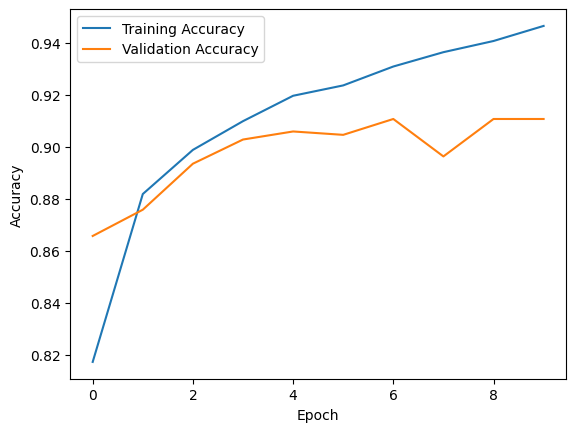

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

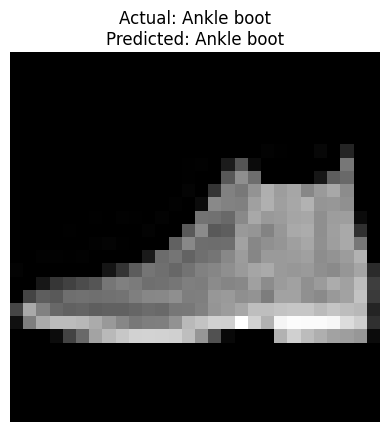

In [10]:

import matplotlib.pyplot as plt
import numpy as np

names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
         'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

i = 0
pred = np.argmax(model.predict(test_images[i:i+1], verbose=0))

plt.imshow(test_images[i].reshape(28,28), cmap='gray')
plt.title(f"Actual: {names[test_labels[i]]}\nPredicted: {names[pred]}")
plt.axis('off')
plt.show()
